In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from PIL import Image, ImageChops
import matplotlib.image as mpimg
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec

from scipy.io import savemat, loadmat

import os

from matplotlib.ticker import FormatStrFormatter, StrMethodFormatter, AutoMinorLocator

dc = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
hbar = 1.054e-34
kB   = 1.38e-23
eps = 1e-15

omega_a = 2 * np.pi * 1.0e9
Theta   = hbar * omega_a / kB # ~0.048 K

T_min, T_max = 0.010, 0.050
nT = 200
T_vals = np.linspace(T_min, T_max, nT)

Delta_min, Delta_max = 1e-2, 100.0
nD = 32000
Delta_vals = np.linspace(Delta_min, Delta_max, nD)

TT, DD = np.meshgrid(T_vals, Delta_vals, indexing='ij')

tau_max = 6.0 
tau_min = 0.01 
T_c     = 0.020 
gamma   = 8.0 

g = 0.05

In [7]:
def n_th(T):
    x = Theta / T
    return 1.0 / (np.exp(x) - 1.0)

def var_n(T):
    nth = n_th(T)
    return nth * (1.0 + nth)

def dvar_n_dT(T):
    nth = n_th(T)
    Var = nth * (1.0 + nth)
    dn_dT = (Theta / T**2) * Var
    return dn_dT * (1.0 + 2.0 * nth)

def Lor(T, Delta):
    r = (T/T_c)**gamma
    tau_c = (tau_max + tau_min * r) / (1.0 + r)
    return np.exp(-Delta/tau_c)

# Fig.2

C:\Users\szhu26\AppData\Local\Temp\ipykernel_13672\3682649628.py:20: RuntimeWarning: divide by zero encountered in log
  ax[0,1].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
C:\Users\szhu26\AppData\Local\Temp\ipykernel_13672\3682649628.py:37: RuntimeWarning: divide by zero encountered in log
  ax[0,2].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
C:\Users\szhu26\AppData\Local\Temp\ipykernel_13672\3682649628.py:56: RuntimeWarning: divide by zero encountered in log
  ax[1,0].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
C:\Users\szhu26\AppData\Local\Temp\ipykernel_13672\3682649628.py:73: RuntimeWarning: divide by zero encountered in log
  ax[1,1].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)


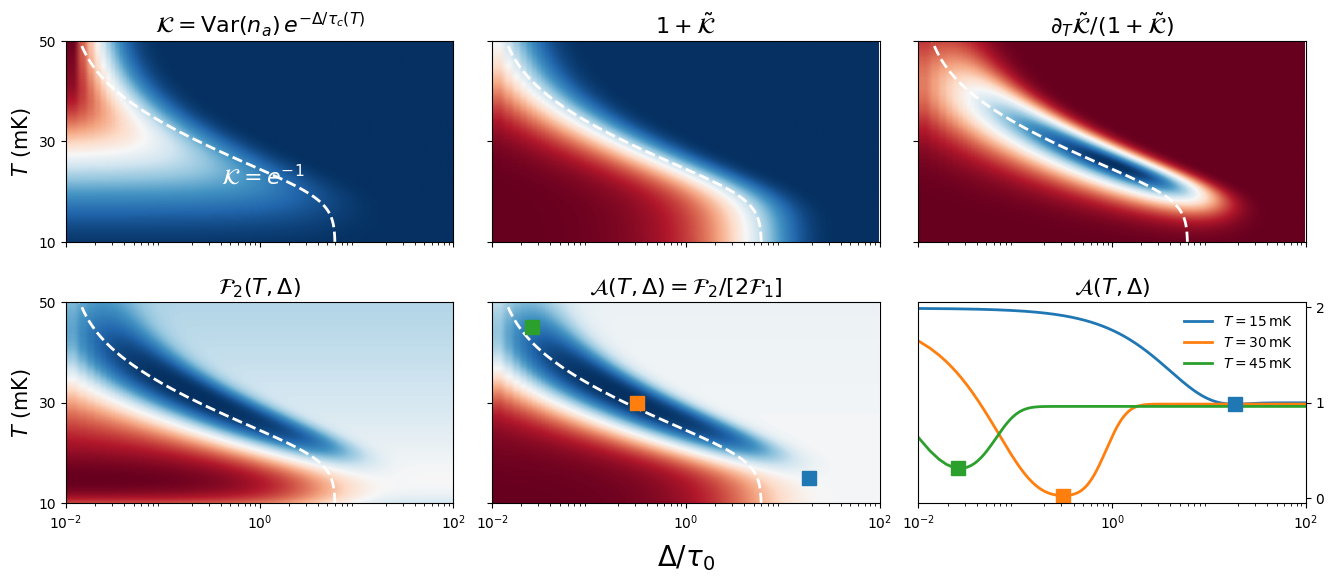

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(16, 6), sharex=True, gridspec_kw={'wspace':0.1, 'hspace': 0.3})

K_grid = var_n(TT)*Lor(TT, DD)

im0 = ax[0, 0].imshow(K_grid, origin='lower', aspect='auto', 
                      extent=[Delta_min, Delta_max, T_min*1e3, T_max*1e3], cmap='RdBu_r',)
ax[0,0].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)+eps), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
ax[0,0].text(0.4, 21.6, r'$\mathcal{K}=e^{-1}$', c='w', fontsize=16)
ax[0,0].set_xticks([1e-2, 1e0, 1e2])
ax[0,0].set_xticks([])
ax[0,0].set_ylabel(r'$T$ (mK)', fontsize=15)
ax[0,0].set_yticks(np.linspace(T_min*1e3, T_max*1e3, 3))
ax[0,0].set_title(r'$\mathcal{K} = \mathrm{Var}(n_a)\,e^{-\Delta / \tau_c(T)}$', fontsize=16)

tildeK_grid = Lor(TT, DD)
K_log = -np.log(tildeK_grid + eps)
K_log_clipped = np.clip(K_log, 0.0, 10.0)
im1 = ax[0,1].imshow(tildeK_grid + 1, origin='lower', aspect='auto', 
                     extent=[Delta_min, Delta_max, T_min*1e3, T_max*1e3], cmap='RdBu_r')
ax[0,1].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
ax[0,1].set_xticks([])
ax[0,1].set_yticks([10, 30, 50])
ax[0,1].set_yticklabels([])
ax[0,1].set_title(r'$1+\tilde{\mathcal{K}}$', fontsize=16)

r1        = (T_vals / T_c)**gamma
tau_c_T   = (tau_max + tau_min * r1) / (1.0 + r1)
dtau_dT   = np.gradient(tau_c_T, T_vals)   
Tau      = tau_c_T[:, None]               
dTau_dT  = dtau_dT[:, None]            
Delta    = Delta_vals[None, :]         

tildeK   = np.exp(-Delta / Tau)          
dK_dT    = tildeK * Delta * dTau_dT / (Tau**2)
im2 = ax[0,2].imshow(dK_dT/(tildeK_grid + 1), origin='lower', aspect='auto', 
                     extent=[Delta_min, Delta_max, T_min*1e3, T_max*1e3], cmap='RdBu_r')
ax[0,2].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
ax[0,2].set_xticks([])
ax[0,2].set_yticks([10, 30, 50])
ax[0,2].set_yticklabels([])
ax[0,2].set_title(r'$\partial_T \tilde{\mathcal{K}} / (1+\tilde{\mathcal{K}})$', fontsize=16)

Var_T     = var_n(T_vals)     
dVar_dT_T = dvar_n_dT(T_vals)  
V_diag = 2 * g * Var_T[:, None]              
V_mem  = 2 * g * Var_T[:, None] * tildeK      
V_tot  = V_diag + V_mem
dV_diag_dT = 2 * g * dVar_dT_T[:, None]
dV_mem_dT  = 2 * g * (dVar_dT_T[:, None] * tildeK + Var_T[:, None] * dK_dT)
dV_tot_dT  = dV_diag_dT + dV_mem_dT
C2    = np.exp(-V_tot)
dC2_dT = -C2 * dV_tot_dT
F2_exact = (dC2_dT**2) / (1.0 - C2**2 + eps)
im3 = ax[1,0].imshow(F2_exact, origin='lower', aspect='auto',
                     extent=[Delta_min, Delta_max, T_min*1e3, T_max*1e3], cmap='RdBu_r')
ax[1,0].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
ax[1,0].set_yticks([10,30,50])
ax[1,0].set_ylabel(r'$T$ (mK)', fontsize=15)
ax[1,0].set_title(r'$\mathcal{F}_2(T,\Delta)$', fontsize=16)

v1_T   = g * Var_T
dv1_dT = g * dVar_dT_T
C1_T       = np.exp(-v1_T)                
dC1_dT     = -C1_T * dv1_dT           
F1_single  = (dC1_dT**2) / (1.0 - C1_T**2 + eps)
F_ind      = 2.0 * F1_single     
A_true = F2_exact / (F_ind[:, None] + eps)
# A_plot = np.clip(A_true, 0.0, 3.0)
idx = np.argmin(A_true, axis=0)
T_ridge = T_vals[idx]
im4 = ax[1,1].imshow(A_true, origin='lower', aspect='auto',
                     extent=[Delta_min, Delta_max, T_min*1e3, T_max*1e3], cmap='RdBu_r')
ax[1,1].contour(Delta_vals, 1e3*T_vals, np.log(Lor(TT, DD)), levels=[-1.0], linestyles='--', colors='w', linewidths=2.0)
T_line_vals = [0.015, 0.030, 0.045]
i = 0
for T0 in T_line_vals:
    idx = np.argmin(np.abs(T_vals - T0))
    ax[1,1].plot(Delta_vals[np.argmin(A_true[idx,:])], 1e3*T_vals[idx], 's', color=dc[i], ms=10)
    i = i+1
ax[1,1].set_xlabel(r'$\Delta / \tau_0$', fontsize=20)
ax[1,1].xaxis.set_label_coords(0.5, -0.2)
ax[1,1].set_yticks([10, 30, 50])
ax[1,1].set_yticklabels([])
ax[1,1].set_title(r'$\mathcal{A}(T,\Delta) = \mathcal{F}_2 / [2\mathcal{F}_1]$', fontsize=16)

ax[1,2].yaxis.set_ticks_position('right')
ax[1,2].yaxis.set_label_position('right')
i = 0
for T0 in T_line_vals:
    idx = np.argmin(np.abs(T_vals - T0))
    ax[1,2].semilogx(Delta_vals, A_true[idx, :], lw=2, color=dc[i], label=rf'$T={T_vals[idx]*1e3:.0f}\,\mathrm{{mK}}$')
    i = i+1
i = 0
for T0 in T_line_vals:
    idx = np.argmin(np.abs(T_vals - T0))
    ax[1,2].plot(Delta_vals[np.argmin(A_true[idx,:])], np.min(A_true[idx,:]), 's', color=dc[i], ms=10)
    i = i+1
ax[1,2].set_xticks([1e-2, 1e0, 1e2])
ax[1,2].set_ylim(-0.05, 2.05)
ax[1,2].set_yticks([0.0,1.0,2.0])
ax[1,2].set_title(r'$\mathcal{A}(T,\Delta)$', fontsize=16)
ax[1,2].legend(frameon=False, fontsize=10)

plt.show()

# Fig.S1

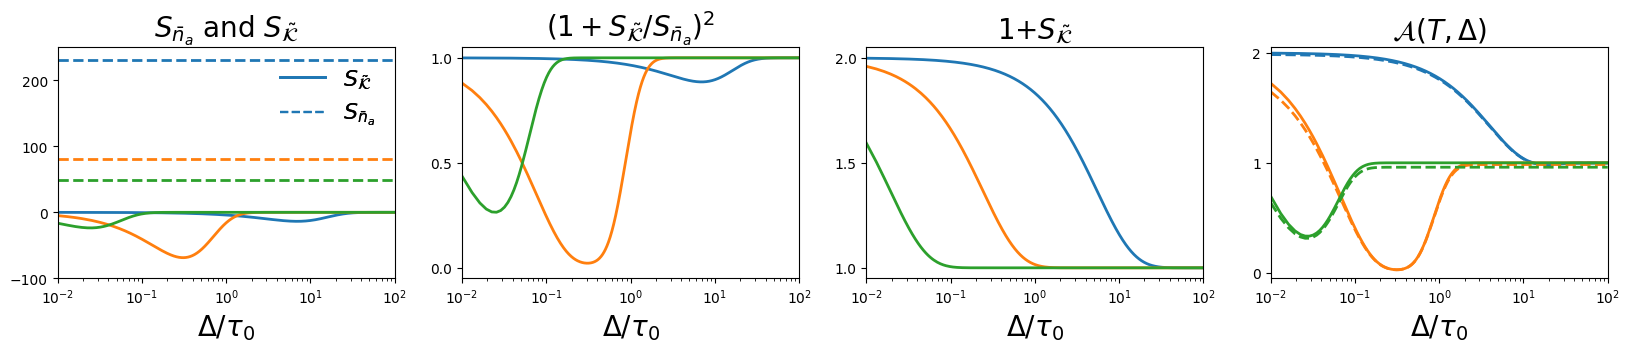

In [9]:
S_n_T = dVar_dT_T / (Var_T + eps)
S_k_grid = dK_dT / (1.0 + tildeK + eps)
ratio_grid = 1.0 + S_k_grid / S_n_T[:, None]
A_from_S = (1.0 + tildeK) * ratio_grid**2 

fig2, ax2 = plt.subplots(1, 4, figsize=(20, 3), sharex=True, gridspec_kw={'wspace':0.2, 'hspace': 0.3})

colors = ['C0', 'C1', 'C2']
for T0, col in zip(T_line_vals, colors):
    idx = np.argmin(np.abs(T_vals - T0))
    T_label = 1e3 * T_vals[idx]  # mK
    ax2[0].semilogx(Delta_vals, S_k_grid[idx,:], color=col, lw=2)
    ax2[0].axhline(S_n_T[idx], color=col, ls='--', lw=2)
from matplotlib.lines import Line2D
style_handles = [
    Line2D([0], [0], color='C0', lw=2, label=r'$S_{\tilde{\mathcal{K}}}$'),
    Line2D([0], [0], color='C0', lw=1.6, ls='--', label=r'$S_{\bar{n}_a}$')
]
leg1 = ax2[0].legend(handles=style_handles, frameon=False, fontsize=16)
ax2[0].add_artist(leg1)  # keep this legend when adding the second
ax2[0].set_xlim(1e-2, 1e2)
ax2[0].set_xlabel(r'$\Delta / \tau_0$', fontsize=20)
ax2[0].set_ylim(-100, 250)
ax2[0].set_yticks([-100, 0, 100, 200])
ax2[0].set_title(r'$S_{\bar{n}_a}$ and $S_{\tilde{\mathcal{K}}}$', fontsize=20)

for T0, col in zip(T_line_vals, colors):
    idx = np.argmin(np.abs(T_vals - T0))
    T_label = 1e3 * T_vals[idx]  # mK
    ax2[1].semilogx(Delta_vals, ratio_grid[idx, :]**2, color=col, lw=2, label=rf'$T={T_label:.0f}\,\mathrm{{mK}}$')
ax2[1].set_xlim(1e-2, 1e2)
ax2[1].set_xlabel(r'$\Delta / \tau_0$', fontsize=20)
ax2[1].set_ylim(-0.05, 1.05)
ax2[1].set_yticks([0.0, 0.5, 1.0])
ax2[1].set_title(r'$(1+S_{\tilde{\mathcal{K}}} / S_{\bar{n}_a})^2$', fontsize=20)

for T0, col in zip(T_line_vals, colors):
    idx = np.argmin(np.abs(T_vals - T0))
    T_label = 1e3 * T_vals[idx]  # mK
    ax2[2].semilogx(Delta_vals, tildeK_grid[idx, :] + 1, color=col, lw=2, label=rf'$T={T_label:.0f}\,\mathrm{{mK}}$')
ax2[2].set_xlim(1e-2, 1e2)
ax2[2].set_xlabel(r'$\Delta / \tau_0$', fontsize=20)
ax2[2].set_title(r'1+$S_{\tilde{\mathcal{K}}}$', fontsize=20)
ax2[2].set_ylim(0.95, 2.05)
ax2[2].set_yticks([1.0, 1.5, 2.0])

for T0, col in zip(T_line_vals, colors):
    idx = np.argmin(np.abs(T_vals - T0))
    T_label = 1e3 * T_vals[idx]
    ax2[3].semilogx(Delta_vals, A_true[idx, :], color=col, lw=2, ls='--')
    ax2[3].semilogx(Delta_vals, A_from_S[idx, :], color=col, lw=2, ls='-')
ax2[3].set_xlim(1e-2, 1e2)
ax2[3].set_xlabel(r'$\Delta / \tau_0$', fontsize=20)
ax2[3].set_ylim(-0.05, 2.05)
ax2[3].set_yticks([0, 1, 2])
ax2[3].set_title(r'$\mathcal{A}(T,\Delta)$', fontsize=20)

plt.show()

# Fig.3

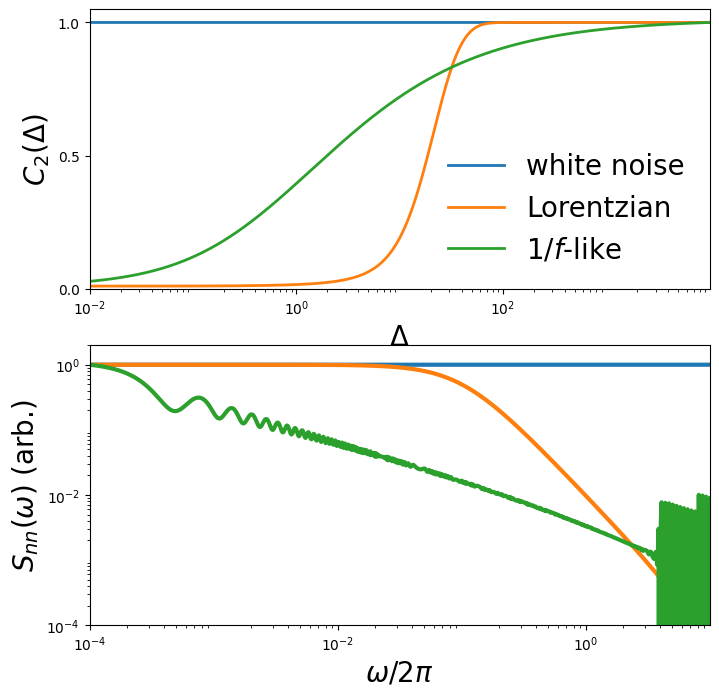

In [14]:
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5  
tau1 = 3.0  
tau2 = 3.0
var_n = 1.0  

base = lam**2 * (tau1**2 + tau2**2) * var_n 
corr_scale = 2 * lam**2 * tau1 * tau2 * var_n  

Delta = np.geomspace(0.001, 10000, 100000)  

sigma_w = 0.001
K_white = np.exp(-(Delta / sigma_w)**2)
K_white /= K_white[0]

tau_c = 10
K_lor = np.exp(-Delta / tau_c)
K_lor   /= K_lor[0]

tau_f = 0.05
gamma = 0.5 
K_1f = 1.0 / (1.0 + (Delta / tau_f)**gamma)
K_1f    /= K_1f[0]

C2_white = np.exp(-(base + corr_scale * K_white))
C2_lor   = np.exp(-(base + corr_scale * K_lor))
C2_1f    = np.exp(-(base + corr_scale * K_1f))

C2_inf_white = C2_white[-1]
C2_inf_lor   = C2_lor[-1]
C2_inf_1f    = C2_1f[-1]

C2_white_norm = C2_white / C2_inf_white
C2_lor_norm   = C2_lor   / C2_inf_lor
C2_1f_norm    = C2_1f    / C2_inf_1f

fig, ax = plt.subplots(2, 1, figsize=(8, 8))

ax[0].semilogx(Delta, C2_white_norm, label='white noise', lw=2)
ax[0].semilogx(Delta, C2_lor_norm,   label='Lorentzian', lw=2)
ax[0].semilogx(Delta, C2_1f_norm,    label=r'$1/f$-like', lw=2)
ax[0].set_xlabel(r'$\Delta$', fontsize=20)
ax[0].set_ylabel(r'$C_2(\Delta)$', fontsize=20)
ax[0].set_xlim(0.01, 10000)
ax[0].set_xticks([0.01, 1, 100])
ax[0].set_ylim(0.0, 1.05) 
ax[0].set_yticks([0.0, 0.5, 1.0])
ax[0].legend(frameon=False, fontsize=20)

def reconstruct_kernel(C2_raw, base, corr_scale):
    return (-np.log(C2_raw) - base) / corr_scale

K_white_rec = reconstruct_kernel(C2_white, base, corr_scale)
K_lor_rec   = reconstruct_kernel(C2_lor,   base, corr_scale)
K_1f_rec    = reconstruct_kernel(C2_1f,    base, corr_scale)

omega = np.logspace(-4, 2, 1000)
def spectrum_from_kernel(K, Delta, omega):
    S = np.zeros_like(omega)
    for i, w in enumerate(omega):
        S[i] = 2 * np.trapezoid(K * np.cos(w * Delta), Delta)
    return S

S_white_rec = spectrum_from_kernel(K_white_rec, Delta, omega)
S_lor_rec   = spectrum_from_kernel(K_lor_rec,   Delta, omega)
S_1f_rec    = spectrum_from_kernel(K_1f_rec,    Delta, omega)
ax[1].loglog(omega, S_white_rec/np.max(S_white_rec), label="white (rec.)", lw=3)
ax[1].loglog(omega, S_lor_rec/np.max(S_lor_rec),     label="Lorentzian (rec.)", lw=3)
ax[1].loglog(omega, S_1f_rec/np.max(S_1f_rec),       label="1/f-like (rec.)", lw=3)
ax[1].set_xlim(1e-4, 1e1)
ax[1].set_ylim(1e-4, 2)
ax[1].set_xticks([1e-4, 1e-2, 1e0])
ax[1].set_yticks([1e-4, 1e-2, 1e0])
ax[1].set_xlabel(r'$\omega / 2\pi$', fontsize=20)
ax[1].set_ylabel(r'$S_{nn}(\omega)$ (arb.)', fontsize=20)

plt.show()